# 06 - CNN from Scratch

1. **original** - `data/split`
2. **CLAHE** - `data/enhanced/clahe`
3. **CLAHE + Gaussian** - `data/enhanced/clahe_gaussian`
4. **GrabCut** (segmentasi) - `data/segmented_grabcut`

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("Device TensorFlow sudah aktif, konfigurasi :", exc)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Konfigurasi & Path

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 20

keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("..").resolve()

# DATASET PATH
DIR_ORIGINAL = PROJECT_ROOT / "data" / "split"

DIR_CLAHE = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe"
)

DIR_CLAHE_GAUSSIAN = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe_gaussian"
)

DIR_GRABCUT = (
    PROJECT_ROOT
    / "data"
    / "segmented_grabcut"
)

# SCENARIOS
SCENARIOS = {
    "original": DIR_ORIGINAL,
    "clahe": DIR_CLAHE,
    "clahe_gaussian": DIR_CLAHE_GAUSSIAN,
    "original_grabcut": DIR_GRABCUT,
}

EXPECTED_CLASSES = [
    "biological",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
]

NUM_CLASSES = len(EXPECTED_CLASSES)

# OUTPUT FOLDER
DIR_METRICS = PROJECT_ROOT / "results" / "metrics"
DIR_FIGURES = PROJECT_ROOT / "results" / "figures"

for d in (DIR_METRICS, DIR_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

# CHECK DATASET
print("Skenario yang akan diuji:")
for nama, p in SCENARIOS.items():
    print(f"{nama:20s} -> {p} (ada: {p.exists()})")

Skenario yang akan diuji:
original             -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\split (ada: True)
clahe                -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe (ada: True)
clahe_gaussian       -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe_gaussian (ada: True)
original_grabcut     -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\segmented_grabcut (ada: True)


## 2. Model & Util

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def load_scenario(base_dir):
    def load(split, shuffle):
        return keras.utils.image_dataset_from_directory(
            base_dir / split, labels="inferred", label_mode="int",
            image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=shuffle, seed=SEED)
    tr = load("train", True); va = load("val", False); te = load("test", False)
    names = tr.class_names
    assert names == EXPECTED_CLASSES, f"Urutan kelas tak sesuai: {names}"
    return (tr.cache().prefetch(AUTOTUNE), va.cache().prefetch(AUTOTUNE),
            te.cache().prefetch(AUTOTUNE))

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")

def build_baseline_cnn():
    """CNN baseline identik dengan notebook 05 (agar adil)."""
    keras.utils.set_random_seed(SEED)
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x); x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="cnn_baseline")
    model.compile(optimizer=keras.optimizers.Adam(),
                  loss=keras.losses.SparseCategoricalCrossentropy(),
                  metrics=["accuracy"])
    return model

def compute_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
            "precision_macro": round(float(p), 4),
            "recall_macro": round(float(r), 4),
            "f1_macro": round(float(f), 4)}

def eval_on_test(model, ds_test):
    yt, yp = [], []
    for xb, yb in ds_test:
        pr = model.predict(xb, verbose=0).argmax(axis=1)
        yt.extend(yb.numpy().tolist()); yp.extend(pr.tolist())
    return np.array(yt), np.array(yp)

In [11]:
cnn_model = build_baseline_cnn()
cnn_model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ORIGINAL
ds_train_original, ds_val_original, ds_test_original = \
    load_scenario(DIR_ORIGINAL)

# CLAHE
ds_train_clahe, ds_val_clahe, ds_test_clahe = \
    load_scenario(DIR_CLAHE)

# CLAHE + GAUSSIAN
ds_train_clahe_gaussian, ds_val_clahe_gaussian, ds_test_clahe_gaussian = \
    load_scenario(DIR_CLAHE_GAUSSIAN)

# ORIGINAL + GRABCUT
ds_train_grabcut, ds_val_grabcut, ds_test_grabcut = \
    load_scenario(DIR_GRABCUT)

print("Dataset berhasil dimuat.")

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Dataset berhasil dimuat.


## 3. Training 

Fungsi untuk ngejalanin eksperimen

In [5]:
def run_experiment(
    scenario_name,
    ds_train,
    ds_val,
    ds_test,
):
    
    print("="*50)
    print("SCENARIO:", scenario_name)
    print("="*50)

    model = build_baseline_cnn()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
        ),
    ]

    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    y_true, y_pred = eval_on_test(
        model,
        ds_test,
    )

    metrics = compute_metrics(
        y_true,
        y_pred,
    )

    metrics.update({
        "scenario": scenario_name,
        "model": "cnn_baseline",
    })

    keras.backend.clear_session()

    return (
        pd.DataFrame([metrics]),
        history,
        y_true,
        y_pred,
    )

### Menjalankan keempat eksperimen

In [7]:
# Eksperimen 1: Dataset Original
results_original, history_original, y_true_ori, y_pred_ori = \
    run_experiment(
        "original",
        ds_train_original,
        ds_val_original,
        ds_test_original,
    )

SCENARIO: original
Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 69s 196ms/step - accuracy: 0.2793 - loss: 1.6575 - val_accuracy: 0.3218 - val_loss: 1.5980 - learning_rate: 0.0010
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 63s 187ms/step - accuracy: 0.3614 - loss: 1.5453 - val_accuracy: 0.3780 - val_loss: 1.5147 - learning_rate: 0.0010
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 69s 205ms/step - accuracy: 0.4144 - loss: 1.4671 - val_accuracy: 0.4308 - val_loss: 1.4276 - learning_rate: 0.0010
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 154s 456ms/step - accuracy: 0.4726 - loss: 1.3742 - val_accuracy: 0.4542 - val_loss: 1.4398 - learning_rate: 0.0010
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 73s 217ms/step - accuracy: 0.4911 - loss: 1.3355 - val_accuracy: 0.4360 - val_loss: 1.4891 - learning_rate: 0.0010
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 74s 218ms/step - accuracy: 0.5322 - loss: 1.2450 - val_accuracy: 0.5285 - val_loss: 1.2952 - learning_rate: 5.0000e-04
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 75s 22

In [8]:
# Eksperimen 2: CLAHE
results_clahe, history_clahe, y_true_clahe, y_pred_clahe = \
    run_experiment(
        "clahe",
        ds_train_clahe,
        ds_val_clahe,
        ds_test_clahe,
    )

SCENARIO: clahe
Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 225s 654ms/step - accuracy: 0.2789 - loss: 1.6593 - val_accuracy: 0.3192 - val_loss: 1.5977 - learning_rate: 0.0010
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 187s 554ms/step - accuracy: 0.3517 - loss: 1.5682 - val_accuracy: 0.3780 - val_loss: 1.5393 - learning_rate: 0.0010
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 204s 603ms/step - accuracy: 0.3933 - loss: 1.4970 - val_accuracy: 0.4074 - val_loss: 1.4877 - learning_rate: 0.0010
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 199s 589ms/step - accuracy: 0.4288 - loss: 1.4438 - val_accuracy: 0.4403 - val_loss: 1.4386 - learning_rate: 0.0010
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 204s 602ms/step - accuracy: 0.4611 - loss: 1.3868 - val_accuracy: 0.4671 - val_loss: 1.4180 - learning_rate: 0.0010
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 192s 567ms/step - accuracy: 0.5093 - loss: 1.3076 - val_accuracy: 0.4870 - val_loss: 1.3909 - learning_rate: 0.0010
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 200s 591

In [9]:
# Eksperimen 3: CLAHE + Gaussian
results_clahe_gaussian, history_clahe_gaussian, y_true_cg, y_pred_cg = \
    run_experiment(
        "clahe_gaussian",
        ds_train_clahe_gaussian,
        ds_val_clahe_gaussian,
        ds_test_clahe_gaussian,
    )

SCENARIO: clahe_gaussian
Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 112s 326ms/step - accuracy: 0.2752 - loss: 1.6710 - val_accuracy: 0.3080 - val_loss: 1.6046 - learning_rate: 0.0010
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 96s 285ms/step - accuracy: 0.3428 - loss: 1.5764 - val_accuracy: 0.3651 - val_loss: 1.5468 - learning_rate: 0.0010
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 95s 280ms/step - accuracy: 0.3832 - loss: 1.5133 - val_accuracy: 0.4066 - val_loss: 1.4849 - learning_rate: 0.0010
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 96s 283ms/step - accuracy: 0.4385 - loss: 1.4411 - val_accuracy: 0.4221 - val_loss: 1.4655 - learning_rate: 0.0010
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 116s 344ms/step - accuracy: 0.4841 - loss: 1.3591 - val_accuracy: 0.5061 - val_loss: 1.3600 - learning_rate: 0.0010
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 94s 278ms/step - accuracy: 0.5100 - loss: 1.2994 - val_accuracy: 0.4585 - val_loss: 1.4275 - learning_rate: 0.0010
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 93s

In [10]:
# Eksperimen 4: Original + Grabcut
results_grabcut, history_grabcut, y_true_gc, y_pred_gc = \
    run_experiment(
        "original_grabcut",
        ds_train_grabcut,
        ds_val_grabcut,
        ds_test_grabcut,
    )

SCENARIO: original_grabcut
Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 204s 593ms/step - accuracy: 0.2871 - loss: 1.6798 - val_accuracy: 0.3313 - val_loss: 1.5995 - learning_rate: 0.0010
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 147s 436ms/step - accuracy: 0.3699 - loss: 1.5679 - val_accuracy: 0.3849 - val_loss: 1.5241 - learning_rate: 0.0010
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 127s 372ms/step - accuracy: 0.3992 - loss: 1.5081 - val_accuracy: 0.4083 - val_loss: 1.4779 - learning_rate: 0.0010
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 180s 534ms/step - accuracy: 0.4272 - loss: 1.4630 - val_accuracy: 0.4196 - val_loss: 1.4410 - learning_rate: 0.0010
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 290s 856ms/step - accuracy: 0.4355 - loss: 1.4448 - val_accuracy: 0.4386 - val_loss: 1.4164 - learning_rate: 0.0010
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 286s 845ms/step - accuracy: 0.4542 - loss: 1.4074 - val_accuracy: 0.4481 - val_loss: 1.3994 - learning_rate: 0.0010
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━

## 4. Tabel & Grafik Perbandingan

In [11]:
results_all = pd.concat([
    results_original,
    results_clahe,
    results_clahe_gaussian,
    results_grabcut,
], ignore_index=True)

display(results_all)

,accuracy,precision_macro,recall_macro,f1_macro,scenario,model
0,0.5765,0.5908,0.5890,0.5842,original,cnn_baseline
1,0.5946,0.6153,0.6018,0.6015,clahe,cnn_baseline
2,0.6465,0.6640,0.6626,0.6579,clahe_gaussian,cnn_baseline
3,0.5609,0.5928,0.5539,0.5639,original_grabcut,cnn_baseline


In [12]:
from sklearn.metrics import confusion_matrix

def plot_confusion_comparison(
    y_true_ori,
    y_pred_ori,
    y_true_clahe,
    y_pred_clahe,
    y_true_cg,
    y_pred_cg,
    y_true_gc,
    y_pred_gc,
    class_names,
):

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(24, 6)
    )

    scenarios = [
        (y_true_ori, y_pred_ori, "Original"),
        (y_true_clahe, y_pred_clahe, "CLAHE"),
        (y_true_cg, y_pred_cg, "CLAHE + Gaussian"),
        (y_true_gc, y_pred_gc, "Original + GrabCut"),
    ]

    for ax, (yt, yp, title) in zip(axes, scenarios):

        cm = confusion_matrix(
            yt,
            yp,
            labels=range(len(class_names))
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
        )

        ax.set_title(title)
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Label Asli")
        ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()

    save_path = (
        DIR_FIGURES
        / "cnn_scratch_confusion_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=120,
        bbox_inches="tight"
    )

    plt.show()

    print("Disimpan:", save_path)

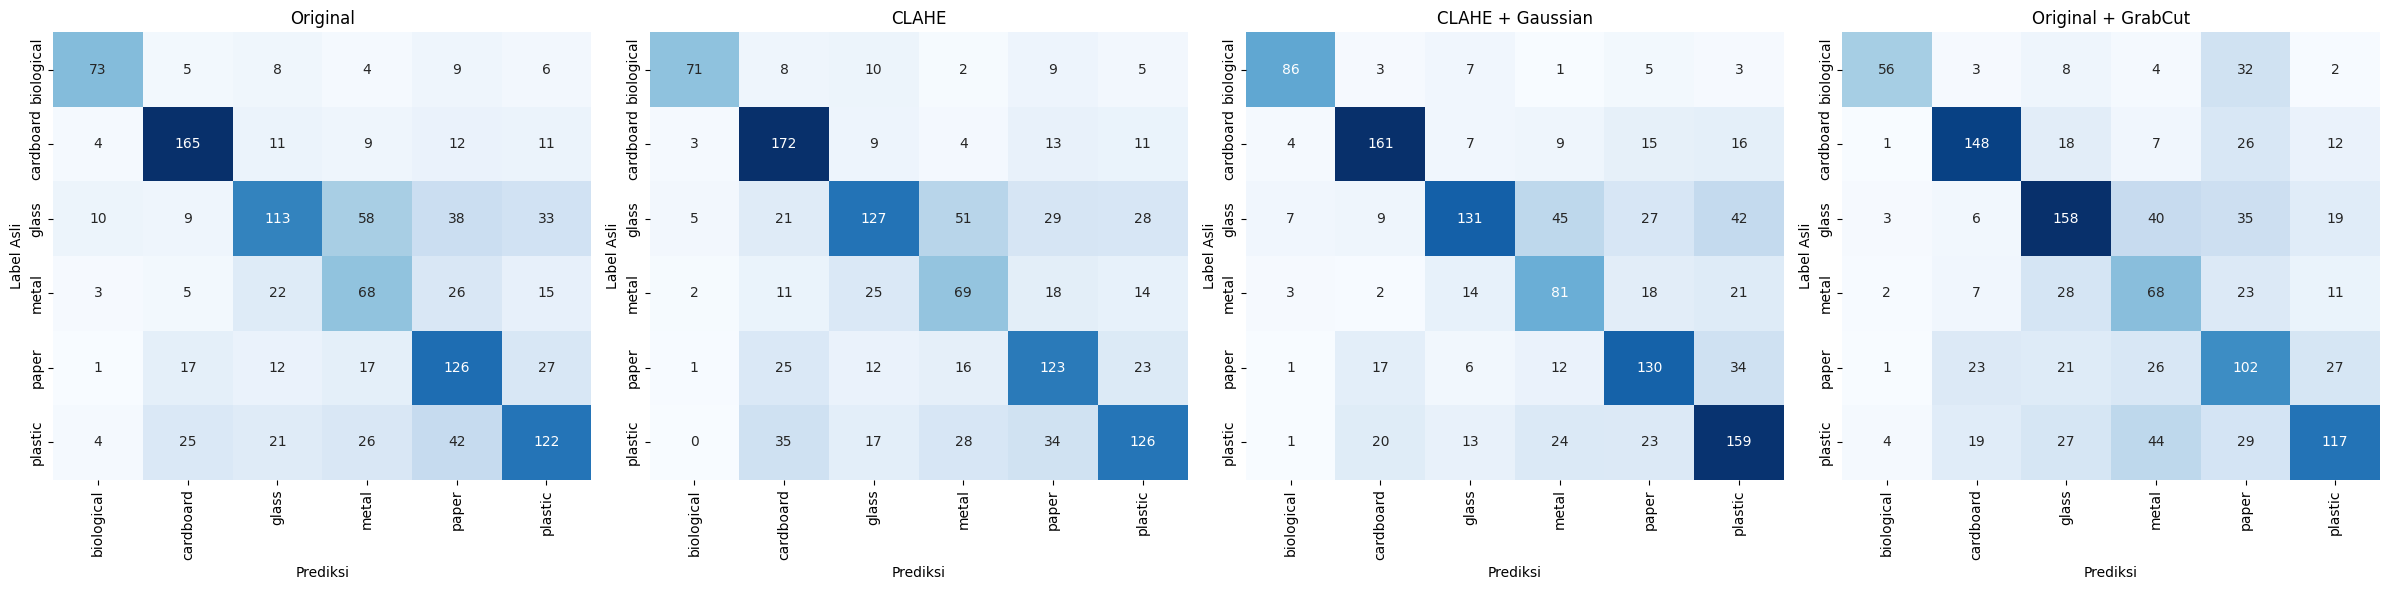

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\cnn_scratch_confusion_comparison.png


In [13]:
plot_confusion_comparison(
    y_true_ori,
    y_pred_ori,
    y_true_clahe,
    y_pred_clahe,
    y_true_cg,
    y_pred_cg,
    y_true_gc,
    y_pred_gc,
    EXPECTED_CLASSES,
)

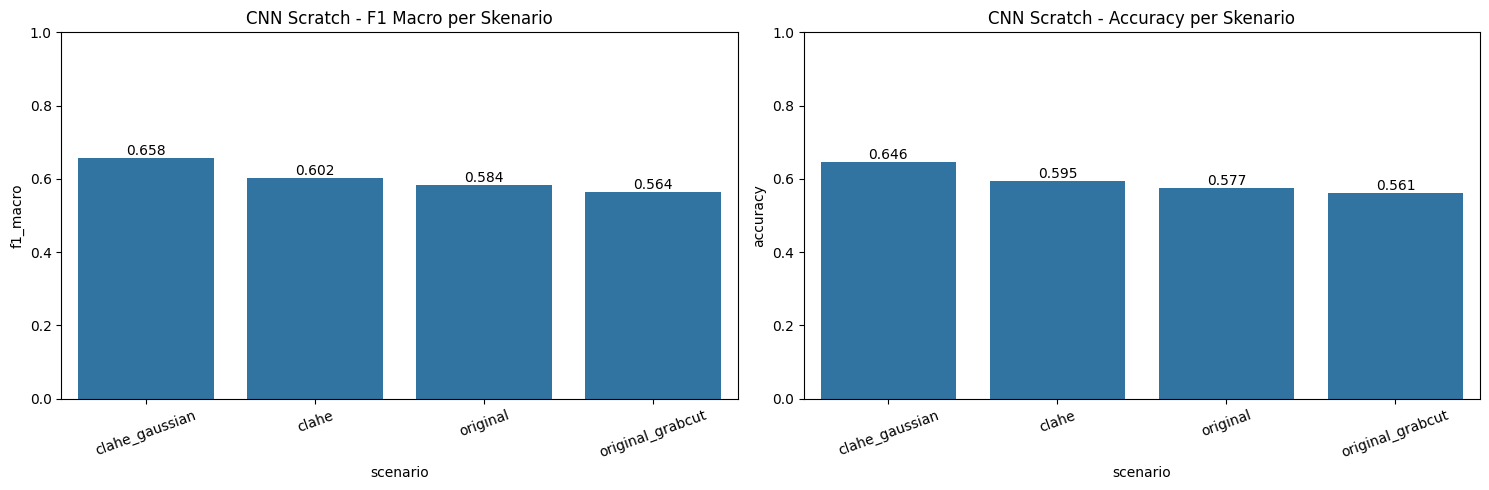

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\cnn_scratch_scenario_comparison.png


In [14]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

order = results_all.sort_values(
    "f1_macro",
    ascending=False
)

# F1 Macro
sns.barplot(
    data=order,
    x="scenario",
    y="f1_macro",
    ax=ax[0],
)

ax[0].set_title(
    "CNN Scratch - F1 Macro per Skenario"
)

ax[0].set_ylim(0, 1)

ax[0].bar_label(
    ax[0].containers[0],
    fmt="%.3f"
)

# Accuracy
sns.barplot(
    data=order,
    x="scenario",
    y="accuracy",
    ax=ax[1],
)

ax[1].set_title(
    "CNN Scratch - Accuracy per Skenario"
)

ax[1].set_ylim(0, 1)

ax[1].bar_label(
    ax[1].containers[0],
    fmt="%.3f"
)

for a in ax:
    a.tick_params(
        axis="x",
        rotation=20
    )

plt.tight_layout()

save_path = (
    DIR_FIGURES
    / "cnn_scratch_scenario_comparison.png"
)

plt.savefig(
    save_path,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print("Disimpan:", save_path)

In [16]:
results_all.to_csv(
    DIR_METRICS / "cnn_scratch_results.csv",
    index=False
)